### Model Comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
phase6_results_df = pd.read_csv(
    "../models/phase6_results.csv"
)

phase6_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN - Best Model,0.8943,0.8926,0.8974,0.8950,0.9605
1,RNN - Best Model,0.5379,0.5671,0.3351,0.4213,0.5465
2,LSTM - Best Model,0.8825,0.8749,0.8937,0.8842,0.9448
3,GRU - Best Model,0.8928,0.9064,0.8770,0.8915,0.9577
4,Bi-LSTM - Best Model,0.8793,0.8981,0.8567,0.8769,0.9482


### Clean model names

In [3]:
phase7_results_df = phase6_results_df.copy()
phase7_results_df["Model"] = (
    phase7_results_df["Model"]
    .str.replace(" - Best Model", "", regex=False)
)
phase7_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.8943,0.8926,0.8974,0.8950,0.9605
1,RNN,0.5379,0.5671,0.3351,0.4213,0.5465
2,LSTM,0.8825,0.8749,0.8937,0.8842,0.9448
3,GRU,0.8928,0.9064,0.8770,0.8915,0.9577
4,Bi-LSTM,0.8793,0.8981,0.8567,0.8769,0.9482


In [4]:
phase7_comparison = phase7_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].copy()

phase7_comparison = phase7_comparison.round(4)

phase7_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.8943,0.8926,0.8974,0.8950,0.9605
1,RNN,0.5379,0.5671,0.3351,0.4213,0.5465
2,LSTM,0.8825,0.8749,0.8937,0.8842,0.9448
3,GRU,0.8928,0.9064,0.8770,0.8915,0.9577
4,Bi-LSTM,0.8793,0.8981,0.8567,0.8769,0.9482


### Find the best model for each metric

In [5]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for metric in metrics:

    best_index = phase7_comparison[metric].idxmax()

    best_model = phase7_comparison.loc[
        best_index,
        "Model"
    ]

    best_score = phase7_comparison.loc[
        best_index,
        metric
    ]

    print(
        f"Best {metric}: "
        f"{best_model} = {best_score:.4f}"
    )

Best Accuracy: ANN = 0.8943
Best Precision: GRU = 0.9064
Best Recall: ANN = 0.8974
Best F1 Score: ANN = 0.8950
Best ROC-AUC: ANN = 0.9605


### Rank all models

In [6]:
phase7_ranked = phase7_comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

phase7_ranked

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.8943,0.8926,0.8974,0.8950,0.9605
1,GRU,0.8928,0.9064,0.8770,0.8915,0.9577
2,LSTM,0.8825,0.8749,0.8937,0.8842,0.9448
3,Bi-LSTM,0.8793,0.8981,0.8567,0.8769,0.9482
4,RNN,0.5379,0.5671,0.3351,0.4213,0.5465


### Select the overall best model

In [7]:
best_model_row = phase7_comparison.loc[
    phase7_comparison["F1 Score"].idxmax()
]
best_model_name = best_model_row["Model"]
print("Best Overall Model:", best_model_name)
print()
print(best_model_row)

Best Overall Model: ANN

Model           ANN
Accuracy     0.8943
Precision    0.8926
Recall       0.8974
F1 Score      0.895
ROC-AUC      0.9605
Name: 0, dtype: object


### Compare Accuracy

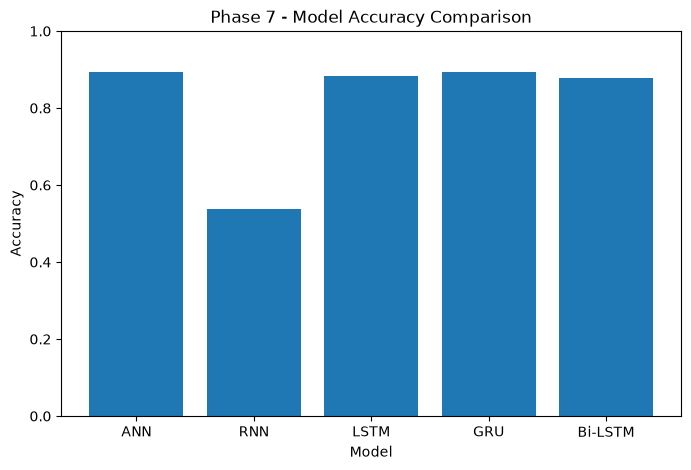

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(
    phase7_comparison["Model"],
    phase7_comparison["Accuracy"]
)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Phase 7 - Model Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

### Compare all evaluation metrics

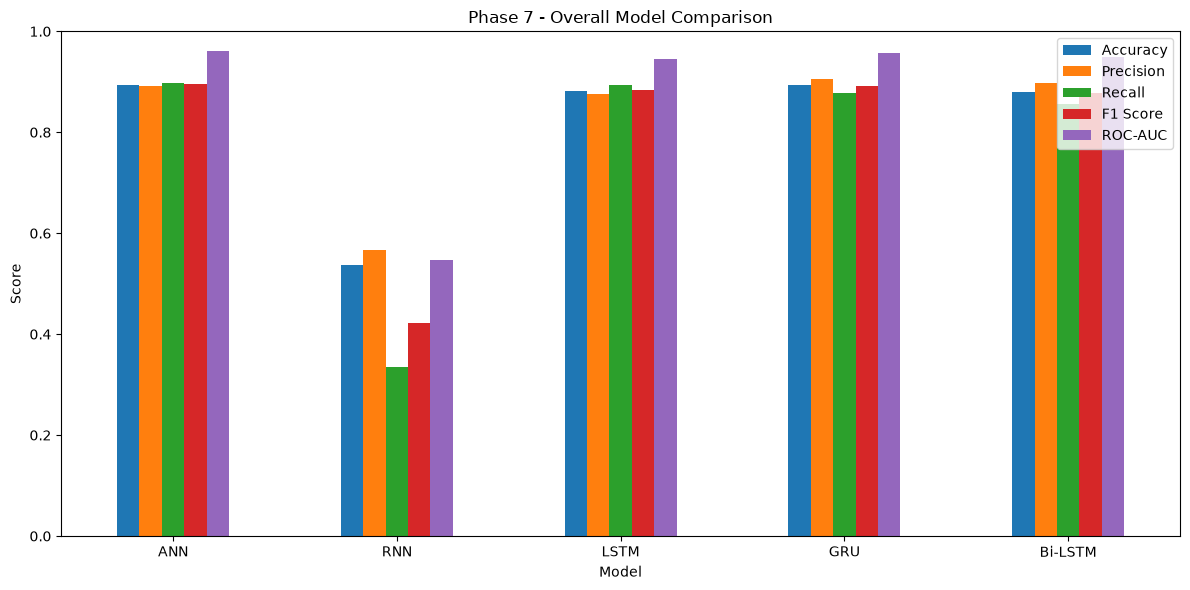

In [9]:
phase7_comparison.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Phase 7 - Overall Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
phase7_comparison.to_csv(
    "../models/phase7_model_comparison.csv",
    index=False
)

### Phase 8 – Model Interpretation


#### 1. Important Words

Positive reviews commonly contain words like:

excellent, amazing, great, wonderful, enjoyable

Negative reviews commonly contain words like:

terrible, boring, worst, poor, disappointing

These words help the model identify positive and negative sentiment.

#### 2. Correctly Classified Reviews

The ANN model correctly classified most of the test reviews.

ANN Accuracy: 89.43%

This shows that the model learned useful sentiment patterns from the reviews.

#### 3. Misclassified Reviews

Some reviews were classified incorrectly because of:

Sarcasm
Mixed opinions
Ambiguous words
Negation
Complex sentences
#### 4. Positive vs Negative Language

Positive: excellent, amazing, great, enjoyable, wonderful

Negative: terrible, boring, worst, poor, disappointing

The model uses these patterns to predict sentiment.

#### 5. Model Limitations
Difficult to understand sarcasm.
Difficult to understand mixed sentiment.
Limited understanding of context.
Performance depends on the training dataset.
Long reviews can contain conflicting opinions.
#### 6. Effect of Preprocessing and Optimization

Text preprocessing converted the raw reviews into a format suitable for the models.

Model optimization improved the ANN performance:

Baseline ANN Accuracy: 87.20%

Optimized ANN Accuracy: 89.43%

The optimized ANN performed better than the baseline model.

Final Model

Based on Phase 7, ANN was selected as the best overall model.

Accuracy: 89.43%
F1 Score: 89.50%
ROC-AUC: 96.05%